# Laboratorio 4, Parte 2 — ejercicios 9 y 10

## Mapas predictivos, análisis y conclusiones

Este notebook aplica el modelo final **XGBoost** a las 22 escenas completas, reconstruye espacialmente las probabilidades, compara las predicciones con la estimación de cianobacteria de la Parte I y sintetiza las conclusiones de todos los experimentos. Se reutilizan exclusivamente artefactos generados en los ejercicios 1–8; no se reentrena ni se selecciona el modelo con estos datos.

## 0. Preparación del entorno

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import average_precision_score, precision_score, recall_score


def localizar_proyecto(inicio=None):
    inicio = Path(inicio or Path.cwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        if candidato.name == 'l04_analisis_geoespacial' and (candidato / 'data').exists():
            return candidato
        anidado = candidato / 'l04_analisis_geoespacial'
        if (anidado / 'data').exists():
            return anidado
    raise FileNotFoundError('No se encontró l04_analisis_geoespacial.')


PROJECT_DIR = localizar_proyecto()
SRC_DIR = PROJECT_DIR / 'parte_2' / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from modelar_ml import PREDICTORAS

PROCESSED_DIR = PROJECT_DIR / 'parte_2' / 'data' / 'processed'
DATASET_DIR = PROCESSED_DIR / 'dataset_ml'
MODELOS_DIR = PROCESSED_DIR / 'modelos'
PRED_DIR = PROCESSED_DIR / 'predicciones_mapas'
OUTPUT_DIR = PROJECT_DIR / 'parte_2' / 'outputs'
PRED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})

manifest_modelos = json.loads((MODELOS_DIR / 'manifest_modelos.json').read_text(encoding='utf-8'))
modelo = joblib.load(MODELOS_DIR / 'estimadores' / 'xgboost.joblib')
UMBRAL = float(manifest_modelos['umbrales_operativos']['XGBoost'])

print(f'Proyecto: {PROJECT_DIR}')
print(f'Escenas procesadas: {len(list(DATASET_DIR.glob("lago=*/fecha=*/observaciones.parquet")))}')
print(f'Umbral operativo XGBoost (máximo F2 en validación): {UMBRAL:.4f}')

Proyecto: C:\Users\sebas\OneDrive\Escritorio\Github\Data sciencie\Data-Science\l04_analisis_geoespacial
Escenas procesadas: 22
Umbral operativo XGBoost (máximo F2 en validación): 0.8172


# 9. Generación de mapas predictivos

## 9.1 Selección del modelo final y alcance de las predicciones

Aunque Random Forest fue el mejor en la partición aleatoria, XGBoost fue superior y más estable en la validación espacial por bloques de 1 km. Por ello se usa el XGBoost ya entrenado en los ejercicios 4–8. La probabilidad se calcula para **cada observación válida de cada una de las 22 escenas**. Para mantener una salida auditable, las predicciones se guardan por lago y fecha en Parquet. `chl_cyano`, la categoría observada y las coordenadas se usan únicamente para evaluación y visualización, nunca como predictores.

In [2]:
metricas_aleatoria = pd.read_csv(MODELOS_DIR / 'metricas_umbral_operativo.csv')
metricas_espacial = pd.read_csv(OUTPUT_DIR / '16_metricas_validacion_espacial_agregado.csv')
fila_aleatoria = metricas_aleatoria.loc[metricas_aleatoria['modelo'] == 'XGBoost'].iloc[0]
fila_espacial = metricas_espacial.loc[metricas_espacial['modelo'] == 'XGBoost'].iloc[0]

seleccion = pd.DataFrame([
    {'validación': 'Aleatoria 70/30', 'PR-AUC': fila_aleatoria.pr_auc,
     'precision': fila_aleatoria.precision, 'recall': fila_aleatoria.recall, 'F2': fila_aleatoria.f2},
    {'validación': 'Espacial (media 5-fold)', 'PR-AUC': fila_espacial.pr_auc_mean,
     'precision': fila_espacial.precision_mean, 'recall': fila_espacial.recall_mean, 'F2': fila_espacial.f2_mean},
])
display(seleccion.style.format({c: '{:.3f}' for c in ['PR-AUC', 'precision', 'recall', 'F2']}))

,validación,PR-AUC,precision,recall,F2
0,Aleatoria 70/30,0.959,0.763,0.977,0.925
1,Espacial (media 5-fold),0.901,0.745,0.916,0.876


### Predicción exhaustiva y diagnóstico por bloques

Además del resumen por escena, los errores se acumulan en bloques UTM de 1 km, la misma unidad utilizada en la validación espacial. Esto permite detectar regiones donde los errores se repiten entre fechas y evita concluir a partir de un único mapa. Las cuatro categorías cartográficas son: muy baja `[0, 0.25)`, baja `[0.25, 0.50)`, alta `[0.50, 0.75)` y muy alta `[0.75, 1]`. La clase operativa, en cambio, conserva el umbral F2 de `0.8172`; las categorías son para lectura visual y no sustituyen ese umbral.

In [3]:
resumen_fuente = pd.read_csv(PROCESSED_DIR / 'resumen_lago_fecha.csv')
resumen_fuente['fecha'] = resumen_fuente['fecha'].astype(str)
fechas_mapa = (resumen_fuente.sort_values('n_clase_1').groupby('lago', observed=True).tail(1)
               .set_index('lago')['fecha'].to_dict())
print('Fechas representativas (máximo número de positivos):', fechas_mapa)

columnas = list(dict.fromkeys(PREDICTORAS + [
    'alta_cyano', 'chl_cyano', 'fila', 'columna', 'x_utm', 'y_utm'
]))
filas_escena = []
partes_bloque = []
escenas_mapa = {}

for archivo in sorted(DATASET_DIR.glob('lago=*/fecha=*/observaciones.parquet')):
    lago = archivo.parent.parent.name.split('=', 1)[1]
    fecha = archivo.parent.name.split('=', 1)[1]
    datos = pd.read_parquet(archivo, columns=columnas)
    prob = modelo.predict_proba(datos[PREDICTORAS])[:, 1].astype('float32')
    observado = datos['alta_cyano'].to_numpy(dtype='uint8')
    predicho = (prob >= UMBRAL).astype('uint8')
    fp = (observado == 0) & (predicho == 1)
    fn = (observado == 1) & (predicho == 0)
    tp = (observado == 1) & (predicho == 1)
    tn = (observado == 0) & (predicho == 0)

    salida_pred = datos[['fila', 'columna', 'x_utm', 'y_utm', 'alta_cyano']].copy()
    salida_pred.insert(0, 'fecha', fecha)
    salida_pred.insert(0, 'lago', lago)
    salida_pred['prob_alta_cyano'] = prob
    salida_pred['pred_alta_cyano'] = predicho
    destino = PRED_DIR / f'lago={lago}' / f'fecha={fecha}'
    destino.mkdir(parents=True, exist_ok=True)
    salida_pred.to_parquet(destino / 'predicciones.parquet', index=False, compression='zstd')

    filas_escena.append({
        'lago': lago, 'fecha': fecha, 'n': len(datos),
        'positivos_observados': int(observado.sum()), 'positivos_predichos': int(predicho.sum()),
        'prevalencia_observada_pct': 100 * observado.mean(),
        'prevalencia_predicha_pct': 100 * predicho.mean(),
        'probabilidad_media': float(prob.mean()),
        'precision': precision_score(observado, predicho, zero_division=0),
        'recall': recall_score(observado, predicho, zero_division=0),
        'pr_auc': average_precision_score(observado, prob),
        'tn': int(tn.sum()), 'fp': int(fp.sum()), 'fn': int(fn.sum()), 'tp': int(tp.sum()),
    })

    bloques = pd.DataFrame({
        'lago': lago, 'bloque_x': np.floor(datos['x_utm'].to_numpy() / 1000).astype('int32'),
        'bloque_y': np.floor(datos['y_utm'].to_numpy() / 1000).astype('int32'),
        'positivo': observado, 'fp': fp.astype('uint8'), 'fn': fn.astype('uint8'),
        'tp': tp.astype('uint8'), 'error': (fp | fn).astype('uint8'),
    })
    partes_bloque.append(bloques.groupby(['lago', 'bloque_x', 'bloque_y'], observed=True)
                          .agg(n=('positivo', 'size'), positivos=('positivo', 'sum'),
                               fp=('fp', 'sum'), fn=('fn', 'sum'), tp=('tp', 'sum'),
                               errores=('error', 'sum')).reset_index())

    if fecha == fechas_mapa[lago]:
        mapa = datos[['fila', 'columna', 'x_utm', 'y_utm', 'chl_cyano', 'alta_cyano']].copy()
        mapa['prob_alta_cyano'] = prob
        mapa['pred_alta_cyano'] = predicho
        mapa['tipo_error'] = np.select([fp, fn, tp], [1, 2, 3], default=0).astype('uint8')
        escenas_mapa[lago] = mapa

    print(f'{lago:10s} {fecha}: {len(datos):>9,} píxeles, TP={tp.sum():>6,}, FP={fp.sum():>6,}, FN={fn.sum():>5,}')

resumen_escenas = pd.DataFrame(filas_escena).sort_values(['lago', 'fecha']).reset_index(drop=True)
errores_bloque = (pd.concat(partes_bloque, ignore_index=True)
                   .groupby(['lago', 'bloque_x', 'bloque_y'], observed=True, as_index=False)
                   [['n', 'positivos', 'fp', 'fn', 'tp', 'errores']].sum())
errores_bloque['x_centro'] = (errores_bloque['bloque_x'] + 0.5) * 1000
errores_bloque['y_centro'] = (errores_bloque['bloque_y'] + 0.5) * 1000
errores_bloque['tasa_error_pct'] = 100 * errores_bloque['errores'] / errores_bloque['n']
errores_bloque['tasa_fp_pct'] = 100 * errores_bloque['fp'] / (errores_bloque['n'] - errores_bloque['positivos']).replace(0, np.nan)
errores_bloque['tasa_fn_pct'] = 100 * errores_bloque['fn'] / errores_bloque['positivos'].replace(0, np.nan)

resumen_escenas.to_csv(OUTPUT_DIR / '27_resumen_predicciones_por_escena.csv', index=False)
errores_bloque.to_csv(OUTPUT_DIR / '28_errores_predictivos_bloques_1km.csv', index=False)
display(resumen_escenas.style.format({c: '{:.3f}' for c in [
    'prevalencia_observada_pct', 'prevalencia_predicha_pct', 'probabilidad_media',
    'precision', 'recall', 'pr_auc']}))

Fechas representativas (máximo número de positivos): {'atitlan': '2026-07-22', 'amatitlan': '2026-06-19'}


amatitlan  2025-01-28:   141,852 píxeles, TP=    15, FP=    11, FN=   19


amatitlan  2025-04-15:   144,251 píxeles, TP=   350, FP=   462, FN=   37


amatitlan  2025-04-28:   144,700 píxeles, TP= 5,785, FP= 6,209, FN=  608


amatitlan  2025-11-24:   143,545 píxeles, TP= 2,464, FP=   631, FN=  100


...

atitlan    2026-03-24: 1,218,766 píxeles, TP=     0, FP=     0, FN=    6


atitlan    2026-04-13: 1,214,717 píxeles, TP=     6, FP=    11, FN=   11


atitlan    2026-04-28: 1,217,053 píxeles, TP=     2, FP=     4, FN=    0


atitlan    2026-07-22: 1,205,034 píxeles, TP=   769, FP= 1,031, FN=  178


,lago,fecha,n,positivos_observados,positivos_predichos,prevalencia_observada_pct,prevalencia_predicha_pct,probabilidad_media,precision,recall,pr_auc,tn,fp,fn,tp
0,amatitlan,2025-01-28,141852,34,26,0.024,0.018,0.001,0.577,0.441,0.479,141807,11,19,15
1,amatitlan,2025-04-15,144251,387,812,0.268,0.563,0.009,0.431,0.904,0.570,143402,462,37,350
2,amatitlan,2025-04-28,144700,6393,11994,4.418,8.289,0.133,0.482,0.905,0.770,132098,6209,608,5785
3,amatitlan,2025-11-24,143545,2564,3095,1.786,2.156,0.024,0.796,0.961,0.952,140350,631,100,2464
4,amatitlan,2026-01-08,146461,8661,10336,5.914,7.057,0.079,0.801,0.956,0.962,135745,2055,380,8281
5,amatitlan,2026-02-02,145437,27,34,0.019,0.023,0.001,0.794,1.000,0.922,145403,7,0,27
6,amatitlan,2026-02-07,65188,1,35,0.002,0.054,0.002,0.000,0.000,0.000,65152,35,1,0
7,amatitlan,2026-03-29,146330,9676,11236,6.612,7.679,0.091,0.836,0.971,0.972,134812,1842,282,9394
8,amatitlan,2026-04-13,147070,2062,3975,1.402,2.703,0.075,0.336,0.648,0.437,142369,2639,726,1336
9,amatitlan,2026-04-28,139628,43927,49731,31.460,35.617,0.376,0.880,0.996,0.990,89742,5959,155,43772


## 9.2–9.5 Reconstrucción espacial y comparación con la Parte I

Se muestra una escena por lago: la fecha con más píxeles de alta presencia observada. Esta regla fue fijada antes de inspeccionar los errores y garantiza que la comparación contenga suficientes positivos. El primer panel reproduce la señal continua de clorofila-a derivada del índice de la Parte I; el segundo muestra la probabilidad del modelo; el tercero discretiza esa probabilidad en cuatro niveles; y el cuarto localiza aciertos y errores usando el umbral operativo. Los huecos blancos son píxeles excluidos por máscara de lago, NoData, reflectancia no plausible o nubosidad residual.

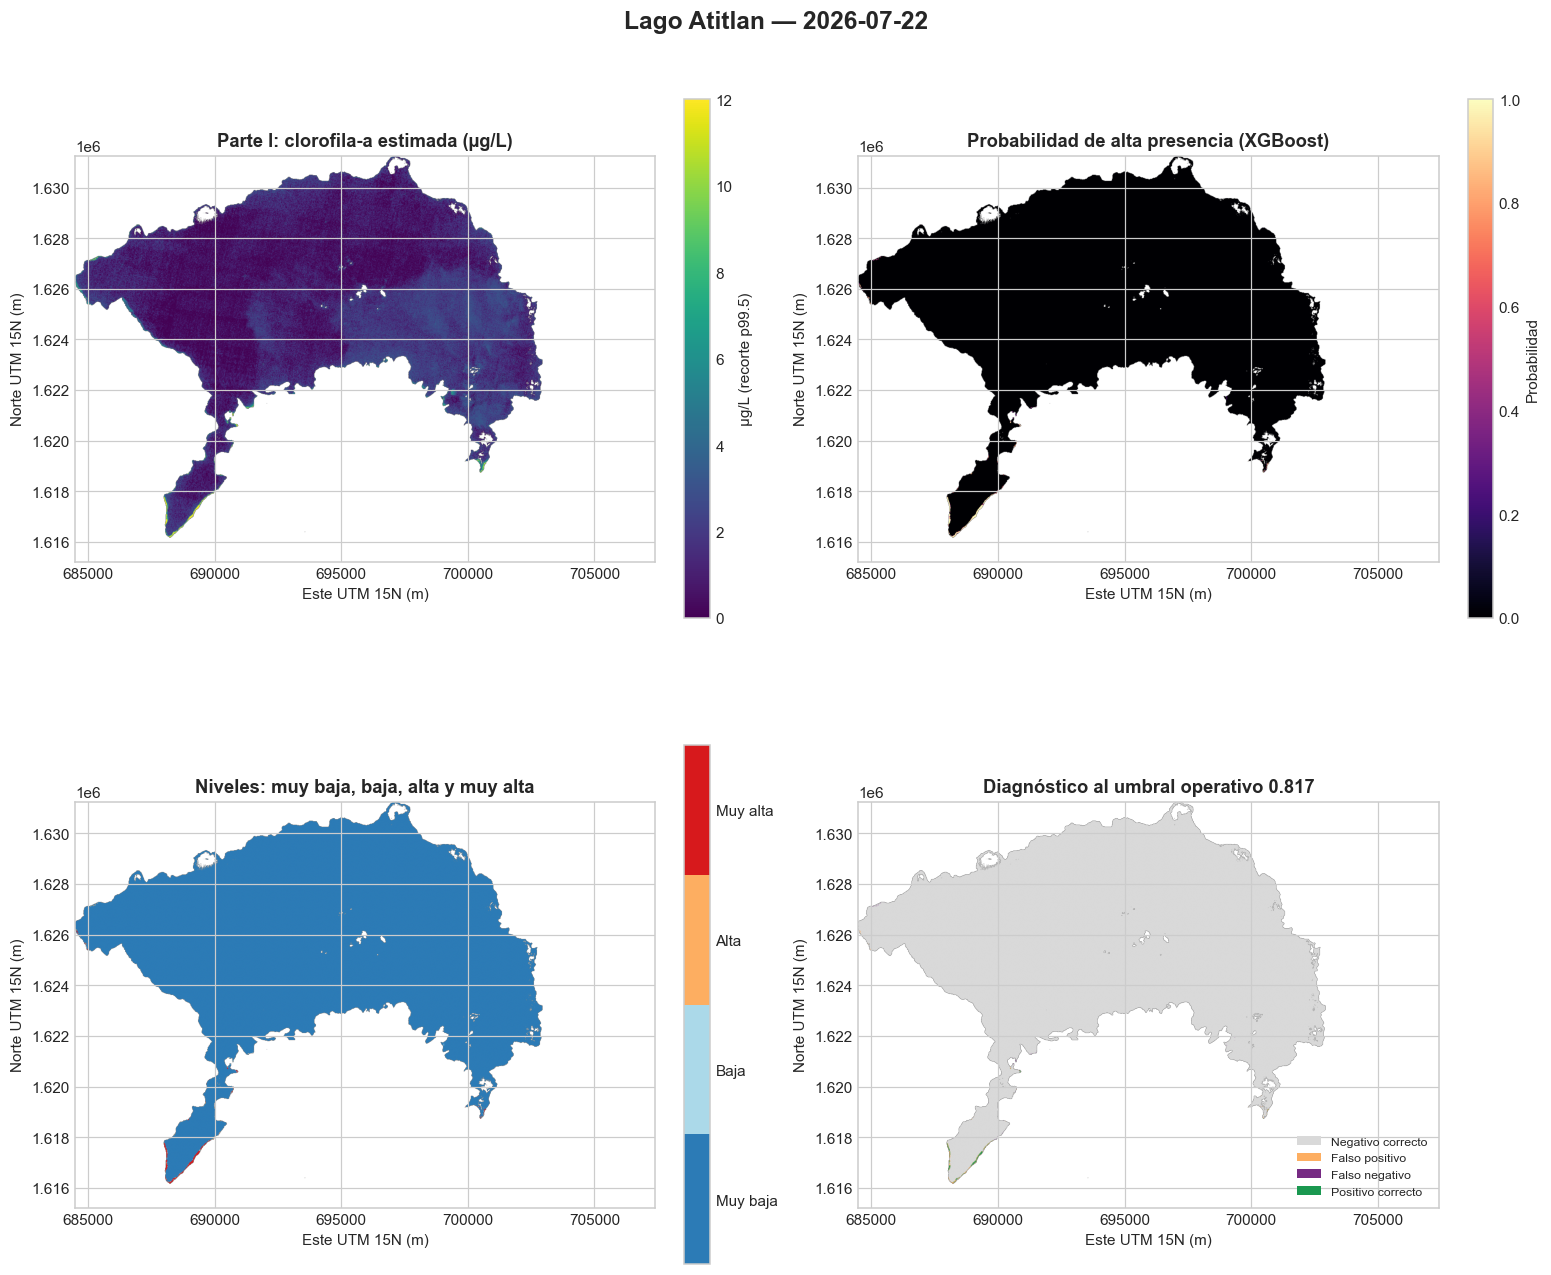

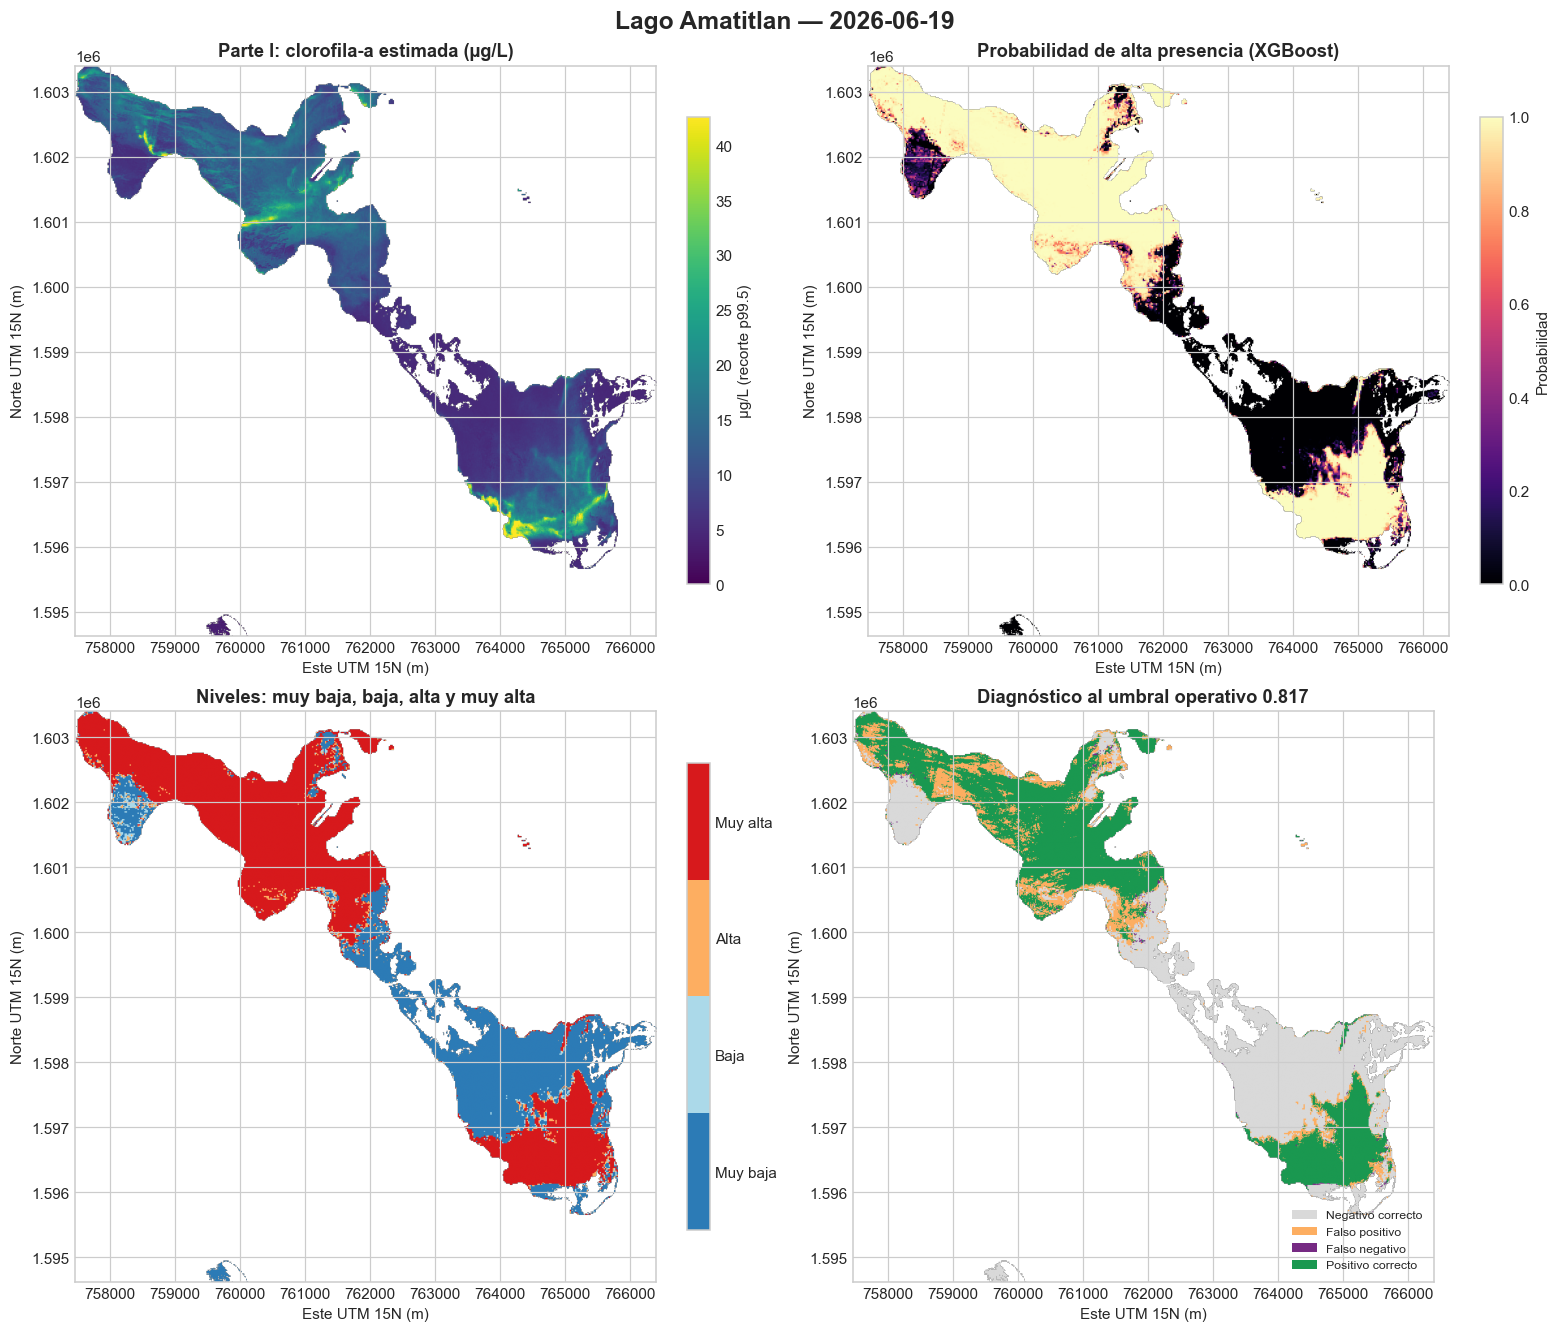

In [4]:
def rasterizar(tabla, variable, dtype='float32'):
    r0, r1 = int(tabla['fila'].min()), int(tabla['fila'].max())
    c0, c1 = int(tabla['columna'].min()), int(tabla['columna'].max())
    matriz = np.full((r1 - r0 + 1, c1 - c0 + 1), np.nan, dtype=dtype)
    matriz[tabla['fila'].to_numpy() - r0, tabla['columna'].to_numpy() - c0] = tabla[variable].to_numpy()
    extent = [tabla['x_utm'].min() - 5, tabla['x_utm'].max() + 5,
              tabla['y_utm'].min() - 5, tabla['y_utm'].max() + 5]
    return matriz, extent

cmap_prob = ListedColormap(['#2c7bb6', '#abd9e9', '#fdae61', '#d7191c'])
norm_prob = BoundaryNorm([0, 0.25, 0.50, 0.75, 1.000001], cmap_prob.N)
cmap_error = ListedColormap(['#d9d9d9', '#fdae61', '#762a83', '#1a9850'])
etiquetas_error = ['Negativo correcto', 'Falso positivo', 'Falso negativo', 'Positivo correcto']

for lago in ['atitlan', 'amatitlan']:
    tabla = escenas_mapa[lago]
    fecha = fechas_mapa[lago]
    chl, extent = rasterizar(tabla, 'chl_cyano')
    prob, _ = rasterizar(tabla, 'prob_alta_cyano')
    errores, _ = rasterizar(tabla, 'tipo_error')
    vmax_chl = max(12, float(np.nanpercentile(chl, 99.5)))

    fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    im0 = axes[0, 0].imshow(chl, extent=extent, origin='upper', cmap='viridis', vmin=0, vmax=vmax_chl)
    axes[0, 0].set_title('Parte I: clorofila-a estimada (µg/L)')
    fig.colorbar(im0, ax=axes[0, 0], shrink=.82, label='µg/L (recorte p99.5)')
    im1 = axes[0, 1].imshow(prob, extent=extent, origin='upper', cmap='magma', vmin=0, vmax=1)
    axes[0, 1].set_title('Probabilidad de alta presencia (XGBoost)')
    fig.colorbar(im1, ax=axes[0, 1], shrink=.82, label='Probabilidad')
    im2 = axes[1, 0].imshow(prob, extent=extent, origin='upper', cmap=cmap_prob, norm=norm_prob)
    axes[1, 0].set_title('Niveles: muy baja, baja, alta y muy alta')
    cb = fig.colorbar(im2, ax=axes[1, 0], shrink=.82, ticks=[.125, .375, .625, .875])
    cb.ax.set_yticklabels(['Muy baja', 'Baja', 'Alta', 'Muy alta'])
    axes[1, 1].imshow(errores, extent=extent, origin='upper', cmap=cmap_error, vmin=0, vmax=3)
    axes[1, 1].set_title(f'Diagnóstico al umbral operativo {UMBRAL:.3f}')
    axes[1, 1].legend(handles=[Patch(facecolor=cmap_error(i), label=e) for i, e in enumerate(etiquetas_error)],
                      loc='lower right', fontsize=8, framealpha=.9)
    for ax in axes.flat:
        ax.set_xlabel('Este UTM 15N (m)')
        ax.set_ylabel('Norte UTM 15N (m)')
        ax.set_aspect('equal')
    fig.suptitle(f'Lago {lago.capitalize()} — {fecha}', fontsize=16, fontweight='bold')
    fig.savefig(OUTPUT_DIR / f'29_mapa_predictivo_{lago}_{fecha}.png', dpi=180, bbox_inches='tight')
    plt.show()

## 9.6–9.7 Falsos positivos, falsos negativos y patrones espaciales de dificultad

Un desacuerdo no es necesariamente un fallo puramente independiente: la etiqueta de referencia también procede de una estimación satelital (NDCI → clorofila-a), no de una medición de laboratorio. Aun así, la persistencia espacial de los desacuerdos revela dónde el modelo es menos confiable. Se reporta la tasa de error total por bloque y, solo donde existen positivos, la tasa de falsos negativos. Los bloques pequeños se conservan en el CSV, pero se exige un mínimo de 1,000 observaciones acumuladas para destacarlos en la tabla.

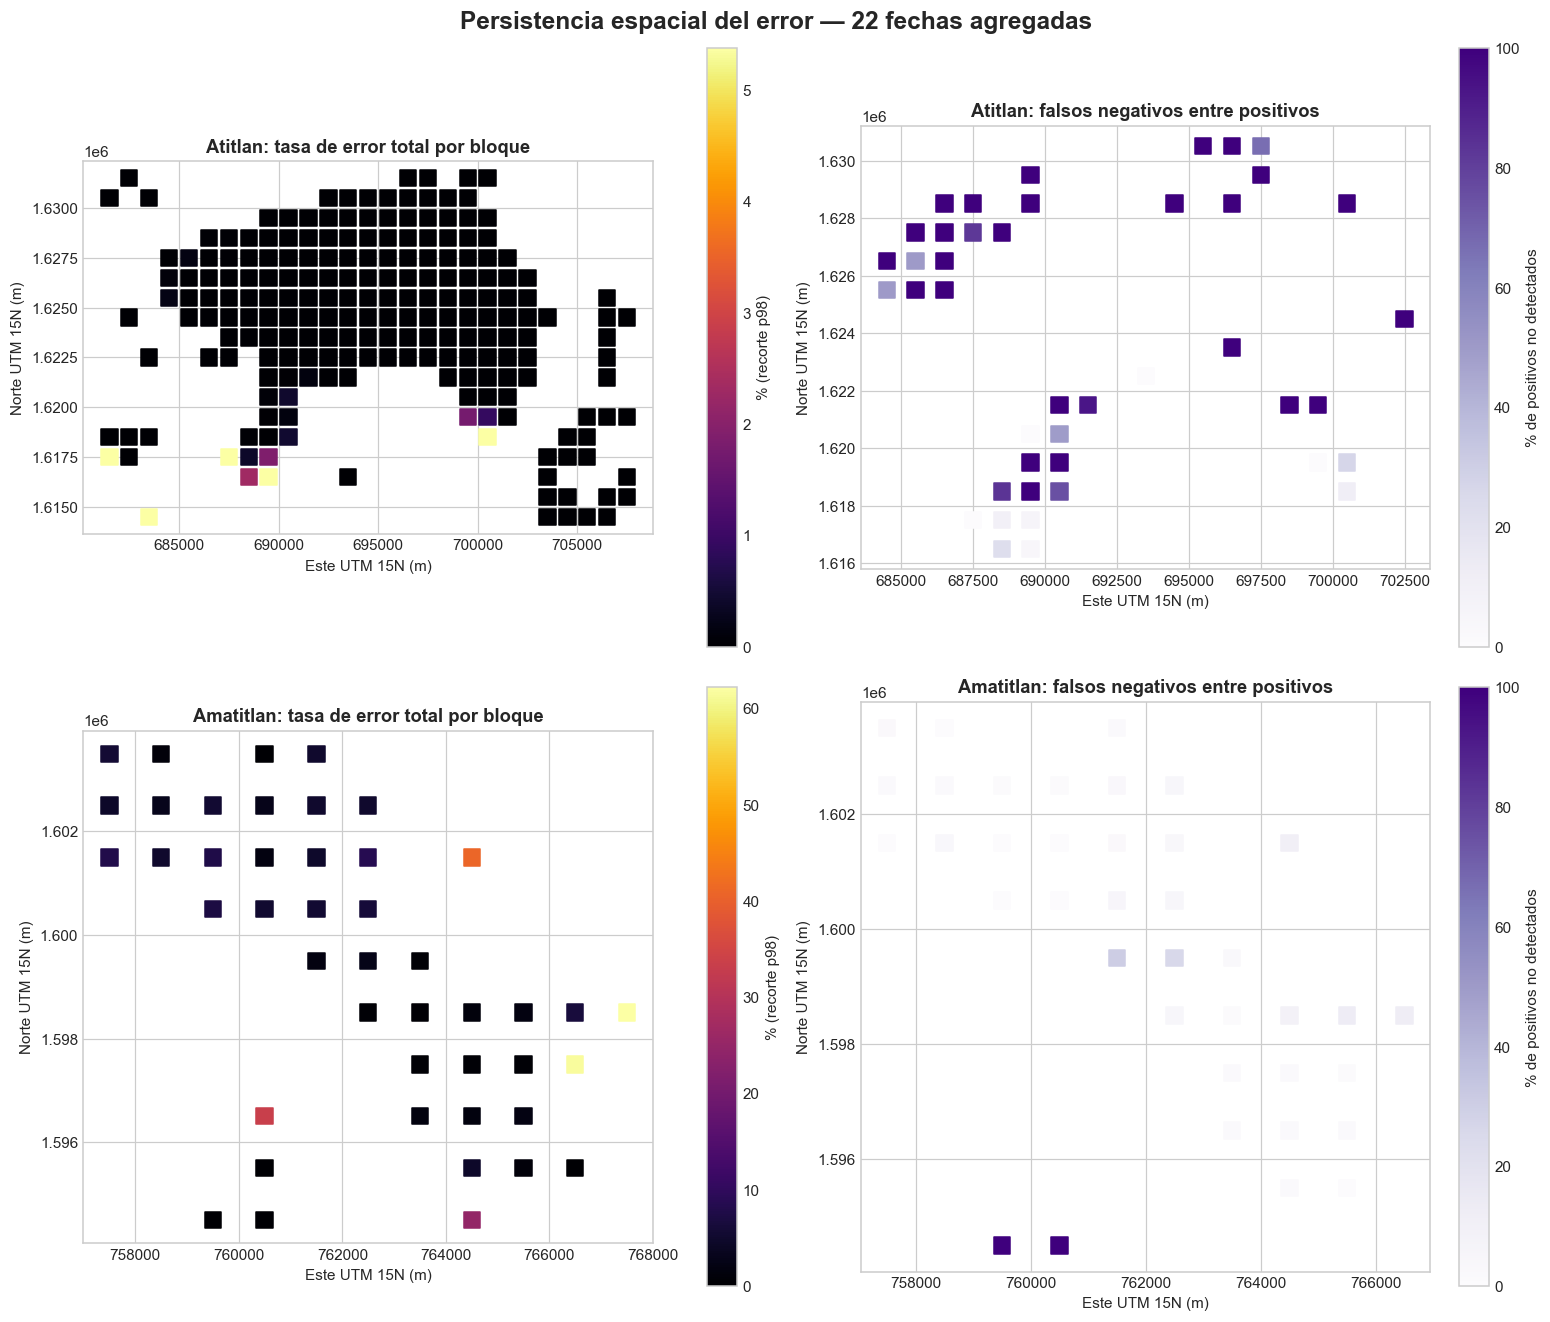

,lago,x_centro,y_centro,n,positivos,fp,fn,tasa_error_pct,tasa_fp_pct,tasa_fn_pct
25,amatitlan,762500.000000,1601500.000000,2895,693,222,28,8.64,10.08,4.04
8,amatitlan,759500.000000,1601500.000000,36634,6416,2797,20,7.69,9.26,0.31
43,amatitlan,766500.000000,1598500.000000,12119,438,738,55,6.54,6.32,12.56
24,amatitlan,762500.000000,1600500.000000,24426,2294,1420,116,6.29,6.42,5.06
2,amatitlan,757500.000000,1603500.000000,17037,3076,900,78,5.74,6.45,2.54
203,atitlan,700500.000000,1618500.000000,3912,498,292,57,8.92,8.55,11.45
77,atitlan,688500.000000,1616500.000000,43170,754,833,168,2.32,1.96,22.28
87,atitlan,689500.000000,1617500.000000,46773,583,838,36,1.87,1.81,6.17
190,atitlan,699500.000000,1619500.000000,1021,6,18,0,1.76,1.77,0.00
204,atitlan,700500.000000,1619500.000000,37092,202,284,54,0.91,0.77,26.73


**Dificultad sistemática en Atitlan.** El mayor error total entre bloques con al menos 1,000 observaciones aparece alrededor de UTM (700,500, 1,618,500), con 8.92 % de desacuerdos acumulados. Entre bloques con al menos 20 positivos, la mayor omisión se ubica alrededor de UTM (685,500, 1,627,500), donde no se detectó 100.0 % de los positivos. Estas coordenadas, junto con el CSV de bloques, identifican las regiones que deben priorizarse para revisión de imágenes y muestreo de campo. La concentración en pocos bloques —y no una degradación uniforme del lago— es coherente con la dependencia espacial observada mediante SHAP y validación por bloques.

**Dificultad sistemática en Amatitlan.** El mayor error total entre bloques con al menos 1,000 observaciones aparece alrededor de UTM (762,500, 1,601,500), con 8.64 % de desacuerdos acumulados. Entre bloques con al menos 20 positivos, la mayor omisión se ubica alrededor de UTM (761,500, 1,599,500), donde no se detectó 30.7 % de los positivos. Estas coordenadas, junto con el CSV de bloques, identifican las regiones que deben priorizarse para revisión de imágenes y muestreo de campo. La concentración en pocos bloques —y no una degradación uniforme del lago— es coherente con la dependencia espacial observada mediante SHAP y validación por bloques.

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
for fila_ax, lago in enumerate(['atitlan', 'amatitlan']):
    sub = errores_bloque.loc[errores_bloque['lago'] == lago]
    s1 = axes[fila_ax, 0].scatter(sub['x_centro'], sub['y_centro'], c=sub['tasa_error_pct'],
                                  cmap='inferno', marker='s', s=115, vmin=0,
                                  vmax=max(1, np.nanpercentile(sub['tasa_error_pct'], 98)))
    axes[fila_ax, 0].set_title(f'{lago.capitalize()}: tasa de error total por bloque')
    fig.colorbar(s1, ax=axes[fila_ax, 0], label='% (recorte p98)')
    con_pos = sub.loc[sub['positivos'] > 0]
    s2 = axes[fila_ax, 1].scatter(con_pos['x_centro'], con_pos['y_centro'], c=con_pos['tasa_fn_pct'],
                                  cmap='Purples', marker='s', s=115, vmin=0, vmax=100)
    axes[fila_ax, 1].set_title(f'{lago.capitalize()}: falsos negativos entre positivos')
    fig.colorbar(s2, ax=axes[fila_ax, 1], label='% de positivos no detectados')
    for ax in axes[fila_ax]:
        ax.set_xlabel('Este UTM 15N (m)')
        ax.set_ylabel('Norte UTM 15N (m)')
        ax.set_aspect('equal')
fig.suptitle('Persistencia espacial del error — 22 fechas agregadas', fontsize=16, fontweight='bold')
fig.savefig(OUTPUT_DIR / '30_mapa_errores_bloques_1km.png', dpi=180, bbox_inches='tight')
plt.show()

bloques_destacados = (errores_bloque.loc[errores_bloque['n'] >= 1000]
                       .sort_values(['lago', 'tasa_error_pct'], ascending=[True, False])
                       .groupby('lago', observed=True).head(5))
display(bloques_destacados[['lago', 'x_centro', 'y_centro', 'n', 'positivos', 'fp', 'fn',
                            'tasa_error_pct', 'tasa_fp_pct', 'tasa_fn_pct']]
        .style.format({c: '{:.2f}' for c in ['tasa_error_pct', 'tasa_fp_pct', 'tasa_fn_pct']}))

for lago in ['atitlan', 'amatitlan']:
    peor = bloques_destacados.loc[bloques_destacados['lago'] == lago].iloc[0]
    sub_pos = errores_bloque.loc[(errores_bloque['lago'] == lago) & (errores_bloque['positivos'] >= 20)]
    peor_fn = sub_pos.sort_values('tasa_fn_pct', ascending=False).iloc[0]
    display(Markdown(
        f'**Dificultad sistemática en {lago.capitalize()}.** El mayor error total entre bloques con al menos '
        f'1,000 observaciones aparece alrededor de UTM ({peor.x_centro:,.0f}, {peor.y_centro:,.0f}), con '
        f'{peor.tasa_error_pct:.2f} % de desacuerdos acumulados. Entre bloques con al menos 20 positivos, '
        f'la mayor omisión se ubica alrededor de UTM ({peor_fn.x_centro:,.0f}, {peor_fn.y_centro:,.0f}), '
        f'donde no se detectó {peor_fn.tasa_fn_pct:.1f} % de los positivos. Estas coordenadas, junto con el '
        'CSV de bloques, identifican las regiones que deben priorizarse para revisión de imágenes y muestreo '
        'de campo. La concentración en pocos bloques —y no una degradación uniforme del lago— es coherente '
        'con la dependencia espacial observada mediante SHAP y validación por bloques.'
    ))

In [6]:
filas_rep = resumen_escenas.merge(
    pd.DataFrame({'lago': list(fechas_mapa), 'fecha': list(fechas_mapa.values())}),
    on=['lago', 'fecha'], how='inner'
)
display(filas_rep[['lago', 'fecha', 'n', 'positivos_observados', 'positivos_predichos',
                   'precision', 'recall', 'pr_auc', 'fp', 'fn', 'tp']]
        .style.format({c: '{:.3f}' for c in ['precision', 'recall', 'pr_auc']}))

for r in filas_rep.itertuples(index=False):
    mensaje = (
        f'**{r.lago.capitalize()} ({r.fecha}).** Las zonas verdes del panel diagnóstico son áreas de alta '
        f'presencia correctamente detectadas (TP={r.tp:,}); las naranjas son falsos positivos (FP={r.fp:,}) '
        f'y las moradas falsos negativos (FN={r.fn:,}). En esta escena, precision={r.precision:.3f}, '
        f'recall={r.recall:.3f} y PR-AUC={r.pr_auc:.3f}. La tabla y el mapa de bloques permiten distinguir '
        'si esos desacuerdos son aislados o se concentran repetidamente en las mismas regiones.'
    )
    display(Markdown(mensaje))

,lago,fecha,n,positivos_observados,positivos_predichos,precision,recall,pr_auc,fp,fn,tp
0,amatitlan,2026-06-19,135896,61178,78394,0.769,0.986,0.955,18076,860,60318
1,atitlan,2026-07-22,1205034,947,1800,0.427,0.812,0.548,1031,178,769


**Amatitlan (2026-06-19).** Las zonas verdes del panel diagnóstico son áreas de alta presencia correctamente detectadas (TP=60,318); las naranjas son falsos positivos (FP=18,076) y las moradas falsos negativos (FN=860). En esta escena, precision=0.769, recall=0.986 y PR-AUC=0.955. La tabla y el mapa de bloques permiten distinguir si esos desacuerdos son aislados o se concentran repetidamente en las mismas regiones.

**Atitlan (2026-07-22).** Las zonas verdes del panel diagnóstico son áreas de alta presencia correctamente detectadas (TP=769); las naranjas son falsos positivos (FP=1,031) y las moradas falsos negativos (FN=178). En esta escena, precision=0.427, recall=0.812 y PR-AUC=0.548. La tabla y el mapa de bloques permiten distinguir si esos desacuerdos son aislados o se concentran repetidamente en las mismas regiones.

# 10. Análisis y conclusiones

In [7]:
generalizacion = pd.read_csv(OUTPUT_DIR / '19_generalizacion_entre_lagos.csv')
xgb_cruzado = generalizacion.loc[
    (generalizacion['modelo'] == 'XGBoost') & generalizacion['escenario'].str.startswith('7.'),
    ['escenario', 'precision', 'recall', 'pr_auc']
].copy()
resumen_lagos = pd.read_csv(PROCESSED_DIR / 'resumen_lago.csv')
total_obs = int(resumen_lagos['observaciones_validas'].sum())
total_pos = int(resumen_lagos['n_clase_1'].sum())

display(Markdown(f'''
## 10.1 ¿Tiene capacidad suficiente como herramienta de monitoreo?

**Sí, pero únicamente como herramienta de apoyo para priorizar inspecciones dentro de los lagos y condiciones representadas en el entrenamiento; no como sistema autónomo ni como sustituto del muestreo físico.** La evidencia favorable es que XGBoost obtuvo PR-AUC **{fila_espacial.pr_auc_mean:.3f}**, recall **{fila_espacial.recall_mean:.3f}** y F2 **{fila_espacial.f2_mean:.3f}** en la validación espacial de cinco folds. Esta es la estimación más defendible para zonas nuevas: es menor que la partición aleatoria (PR-AUC {fila_aleatoria.pr_auc:.3f}, recall {fila_aleatoria.recall:.3f}), pero conserva buena sensibilidad. Los mapas muestran además que la salida es espacialmente interpretable y permite dirigir muestreos hacia zonas de probabilidad alta o muy alta.

La recomendación tiene límites importantes. El conjunto reúne **{total_obs:,}** píxeles válidos, pero solo **{total_pos:,}** positivos ({100*total_pos/total_obs:.3f} %), y la prueba entre lagos demostró que el desempeño no se transfiere de forma segura: XGBoost logró PR-AUC **{xgb_cruzado.iloc[0].pr_auc:.3f}** al entrenar en Atitlán y evaluar en Amatitlán, y **{xgb_cruzado.iloc[1].pr_auc:.3f}** en la dirección inversa. Además, SHAP mostró dependencia fuerte de `b07` —una señal física útil— pero también de `x_utm`/`y_utm`, evidencia de aprendizaje de patrones locales. Por tanto, las probabilidades sirven como **alerta y priorización**, siempre acompañadas de control de calidad, revisión de incertidumbre y confirmación in situ.

Desde el punto de vista ambiental se priorizó el recall mediante un umbral que maximiza F2: no detectar una floración puede retrasar avisos sanitarios y acciones de manejo. El costo aceptado es una mayor cantidad de falsos positivos, que implican inspecciones adicionales pero son reversibles.

## 10.2 Principales limitaciones

- **Referencia imperfecta:** `alta_cyano` se construyó con clorofila-a estimada por NDCI, no con conteos de cianobacterias o toxinas medidos en campo. Los mapas comparan el modelo contra otra estimación satelital; no constituyen validación biológica independiente.
- **Desbalance y cobertura temporal:** hay 22 fechas y cerca de 1 % de positivos globales. Atitlán aporta muy pocos positivos, por lo que sus métricas tienen mayor incertidumbre y el modelo aprende sobre todo el régimen de Amatitlán.
- **Autocorrelación espacial:** píxeles vecinos no son observaciones independientes. La caída de PR-AUC de {fila_aleatoria.pr_auc:.3f} a {fila_espacial.pr_auc_mean:.3f} confirma que la división aleatoria era optimista.
- **Diferencias entre lagos:** prevalencia, profundidad, estado trófico, sedimentos, materia orgánica y presión urbana cambian la respuesta espectral. Los experimentos cruzados no respaldan aplicar el modelo sin recalibración a otro lago.
- **Resolución y mezcla de píxeles:** aunque el análisis usa una cuadrícula de 10 m, las bandas red-edge de Sentinel-2 tienen resolución nativa de 20 m y fueron remuestreadas. En orillas, desembocaduras y parches pequeños puede existir mezcla de agua, suelo y vegetación.
- **Nubosidad y calidad atmosférica:** se descartaron escenas/píxeles problemáticos mediante umbrales y una heurística de nube brillante, pero pueden persistir nubes delgadas, sombras, bruma, destellos solares y diferencias de corrección atmosférica.
- **Calibración y deriva:** el umbral y los pesos de clase reflejan estas fechas y prevalencias. Cambios estacionales, climáticos o de sensor pueden volver las probabilidades menos calibradas.
- **Atajos espaciales:** la importancia de coordenadas e identidad del lago mejora el ajuste local, pero reduce la portabilidad. Un patrón histórico de riesgo puede confundirse con una relación ambiental estable.

## 10.3 Información adicional que mejoraría el modelo

1. **Muestreo físico georreferenciado y sincronizado con Sentinel-2:** clorofila-a, ficocianina, densidad y taxonomía de cianobacterias, microcistinas, turbidez, transparencia Secchi, oxígeno disuelto, pH y nutrientes (N y P). Es la mejora prioritaria porque crea una referencia independiente.
2. **Variables meteorológicas:** temperatura del aire y del agua, radiación solar, viento, precipitación acumulada y eventos extremos, con rezagos de días o semanas.
3. **Variables hidrológicas:** caudal y carga de nutrientes de tributarios, nivel del lago, tiempo de residencia, corrientes y distancia a desembocaduras o descargas.
4. **Mayor densidad temporal y estacional:** más años, fechas durante floraciones y observaciones posteriores a lluvias; idealmente combinar Sentinel-2 con Landsat, sensores de mayor frecuencia o mediciones con dron.
5. **Mejor información óptica:** corrección atmosférica específica para agua, máscaras de nubes/sombras validadas, bandas adicionales y variables físicamente motivadas. Deben auditarse para evitar reutilizar directa o indirectamente las bandas que construyen la respuesta.
6. **Diseño de validación externo:** reservar fechas completas, campañas futuras y, si se amplía el alcance, lagos no vistos. También conviene calibrar probabilidades por lago y reportar intervalos de incertidumbre.

### Conclusión final

El modelo logra localizar patrones de alta presencia dentro del dominio estudiado y mantiene un recall espacial alto, por lo que puede reducir el área que necesita inspección. Sin embargo, la escasez de positivos en Atitlán, la referencia satelital no independiente, la caída bajo validación espacial y el fracaso de transferencia entre lagos impiden considerarlo un sistema operacional autónomo. La siguiente etapa debe priorizar validación de campo, más fechas positivas y evaluación prospectiva antes de emitir alertas ambientales o sanitarias.
'''))


## 10.1 ¿Tiene capacidad suficiente como herramienta de monitoreo?

**Sí, pero únicamente como herramienta de apoyo para priorizar inspecciones dentro de los lagos y condiciones representadas en el entrenamiento; no como sistema autónomo ni como sustituto del muestreo físico.** La evidencia favorable es que XGBoost obtuvo PR-AUC **0.901**, recall **0.916** y F2 **0.876** en la validación espacial de cinco folds. Esta es la estimación más defendible para zonas nuevas: es menor que la partición aleatoria (PR-AUC 0.959, recall 0.977), pero conserva buena sensibilidad. Los mapas muestran además que la salida es espacialmente interpretable y permite dirigir muestreos hacia zonas de probabilidad alta o muy alta.

La recomendación tiene límites importantes. El conjunto reúne **13,689,403** píxeles válidos, pero solo **137,708** positivos (1.006 %), y la prueba entre lagos demostró que el desempeño no se transfiere de forma segura: XGBoost logró PR-AUC **0.272** al entrenar en Atitlán y evaluar en Amatitlán, y **0.295** en la dirección inversa. Además, SHAP mostró dependencia fuerte de `b07` —una señal física útil— pero también de `x_utm`/`y_utm`, evidencia de aprendizaje de patrones locales. Por tanto, las probabilidades sirven como **alerta y priorización**, siempre acompañadas de control de calidad, revisión de incertidumbre y confirmación in situ.

Desde el punto de vista ambiental se priorizó el recall mediante un umbral que maximiza F2: no detectar una floración puede retrasar avisos sanitarios y acciones de manejo. El costo aceptado es una mayor cantidad de falsos positivos, que implican inspecciones adicionales pero son reversibles.

## 10.2 Principales limitaciones

- **Referencia imperfecta:** `alta_cyano` se construyó con clorofila-a estimada por NDCI, no con conteos de cianobacterias o toxinas medidos en campo. Los mapas comparan el modelo contra otra estimación satelital; no constituyen validación biológica independiente.
- **Desbalance y cobertura temporal:** hay 22 fechas y cerca de 1 % de positivos globales. Atitlán aporta muy pocos positivos, por lo que sus métricas tienen mayor incertidumbre y el modelo aprende sobre todo el régimen de Amatitlán.
- **Autocorrelación espacial:** píxeles vecinos no son observaciones independientes. La caída de PR-AUC de 0.959 a 0.901 confirma que la división aleatoria era optimista.
- **Diferencias entre lagos:** prevalencia, profundidad, estado trófico, sedimentos, materia orgánica y presión urbana cambian la respuesta espectral. Los experimentos cruzados no respaldan aplicar el modelo sin recalibración a otro lago.
- **Resolución y mezcla de píxeles:** aunque el análisis usa una cuadrícula de 10 m, las bandas red-edge de Sentinel-2 tienen resolución nativa de 20 m y fueron remuestreadas. En orillas, desembocaduras y parches pequeños puede existir mezcla de agua, suelo y vegetación.
- **Nubosidad y calidad atmosférica:** se descartaron escenas/píxeles problemáticos mediante umbrales y una heurística de nube brillante, pero pueden persistir nubes delgadas, sombras, bruma, destellos solares y diferencias de corrección atmosférica.
- **Calibración y deriva:** el umbral y los pesos de clase reflejan estas fechas y prevalencias. Cambios estacionales, climáticos o de sensor pueden volver las probabilidades menos calibradas.
- **Atajos espaciales:** la importancia de coordenadas e identidad del lago mejora el ajuste local, pero reduce la portabilidad. Un patrón histórico de riesgo puede confundirse con una relación ambiental estable.

## 10.3 Información adicional que mejoraría el modelo

1. **Muestreo físico georreferenciado y sincronizado con Sentinel-2:** clorofila-a, ficocianina, densidad y taxonomía de cianobacterias, microcistinas, turbidez, transparencia Secchi, oxígeno disuelto, pH y nutrientes (N y P). Es la mejora prioritaria porque crea una referencia independiente.
2. **Variables meteorológicas:** temperatura del aire y del agua, radiación solar, viento, precipitación acumulada y eventos extremos, con rezagos de días o semanas.
3. **Variables hidrológicas:** caudal y carga de nutrientes de tributarios, nivel del lago, tiempo de residencia, corrientes y distancia a desembocaduras o descargas.
4. **Mayor densidad temporal y estacional:** más años, fechas durante floraciones y observaciones posteriores a lluvias; idealmente combinar Sentinel-2 con Landsat, sensores de mayor frecuencia o mediciones con dron.
5. **Mejor información óptica:** corrección atmosférica específica para agua, máscaras de nubes/sombras validadas, bandas adicionales y variables físicamente motivadas. Deben auditarse para evitar reutilizar directa o indirectamente las bandas que construyen la respuesta.
6. **Diseño de validación externo:** reservar fechas completas, campañas futuras y, si se amplía el alcance, lagos no vistos. También conviene calibrar probabilidades por lago y reportar intervalos de incertidumbre.

### Conclusión final

El modelo logra localizar patrones de alta presencia dentro del dominio estudiado y mantiene un recall espacial alto, por lo que puede reducir el área que necesita inspección. Sin embargo, la escasez de positivos en Atitlán, la referencia satelital no independiente, la caída bajo validación espacial y el fracaso de transferencia entre lagos impiden considerarlo un sistema operacional autónomo. La siguiente etapa debe priorizar validación de campo, más fechas positivas y evaluación prospectiva antes de emitir alertas ambientales o sanitarias.


## Comprobaciones de integridad

Estas aserciones verifican que se puntuaron las 22 escenas y todas las observaciones válidas, que las probabilidades están en `[0,1]`, que cada lago tiene un mapa y que las cuentas de la matriz de confusión cierran.

In [8]:
assert len(resumen_escenas) == 22
assert int(resumen_escenas['n'].sum()) == total_obs
assert set(escenas_mapa) == {'atitlan', 'amatitlan'}
assert np.allclose(resumen_escenas[['tn', 'fp', 'fn', 'tp']].sum(axis=1), resumen_escenas['n'])
for archivo in PRED_DIR.glob('lago=*/fecha=*/predicciones.parquet'):
    limites = pd.read_parquet(archivo, columns=['prob_alta_cyano'])['prob_alta_cyano']
    assert limites.between(0, 1).all()
assert len(list(PRED_DIR.glob('lago=*/fecha=*/predicciones.parquet'))) == 22
print(f'Validación completa: {total_obs:,} observaciones, 22 escenas y 2 mapas predictivos.')

Validación completa: 13,689,403 observaciones, 22 escenas y 2 mapas predictivos.
